## Annual Climate Data for Death Valley, California

In [1]:
### import libraries
import earthpy ### manage local data
import holoviews as hv ### save interactive plots
import hvplot ### plotting
import hvplot.pandas ### make interactive plots
import pandas as pd ### work with tabular data in data frames

import matplotlib.pyplot as plt ### plotting tool
import seaborn as sns ### statistical plots

from sklearn.linear_model import LinearRegression ### fit an OLS linear regression

from osmnx import features as osm ### search for locations in open street map
import geopandas as gpd ### work with vectors

In [2]:
### Set weather station information 

### NCEI base url
ncei_base = 'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries'

### Look up desired location station: https://www.ncdc.noaa.gov/cdo-web/search
### Selected Station Data URL: https://www.ncdc.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00042319/detail

### Review station information and data availability and use to fill in fields below

### Station Name
station_name = 'Death Valley National Park, CA'

### Station ID
station_id = 'USC00042319'
url_station = '&stations='+station_id

### Data Type
climate_data_type = 'TOBS,TMAX,TMIN'
url_data_type = '&dataTypes='+climate_data_type

### Data Record Start Date
start_date = '1962-01-01' # observations start date: 1961-04-26
url_start = '&startDate='+start_date

### Data Record End Date
end_date = '2021-12-31' # last date with recorded TOBS
url_end = '&endDate='+end_date

### Data Units (standard (F) or metric (C))
data_units = 'metric'
url_units = '&units='+data_units

### Assemble full URL concatenating pieces assembled above

ncei_url = ncei_base + url_data_type + url_station + url_start + url_end+url_units

### Review concatenated URL
print(ncei_url)


https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS,TMAX,TMIN&stations=USC00042319&startDate=1962-01-01&endDate=2021-12-31&units=metric


In [3]:
# Load climate data from NCEI into data frame
climate_df = pd.read_csv(ncei_url, 
    index_col = 'DATE', parse_dates = True, na_values = ['NaN']
    )


Data records for Death Valley National Park start on 1961-04-26 and claim to run through 2026. While there are min and max values recorded through the 2026 data, the observed temperature values are NaN starting in 2022. This was verified by spot checking data using the Quick Data reports on station website (https://www.ncdc.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00042319/detail). Additional internet queries indicated that changes were made to some of the Death Valley data collection after 2021 and there are changes being made to how Death Valley data is being stored and reported digitally (https://www.weather.gov/vef/deathvalley_climatebook). 

Additionally, due to the large temperature swings of the high desert, using the partial year data for 1961 created a large disparity between the average temperature for 1961 and for 1962 and later. Thus, the data was filtered to run from 1962-01-01 to 2021-12-31.

In [4]:
### Check to make sure data exists for selected dates and verify units look correct

# beginning of data set
print(climate_df.head())

# end of data set 
print(climate_df.tail())

                STATION  TMAX  TMIN  TOBS
DATE                                     
1962-01-01  USC00042319  13.9   6.7  12.8
1962-01-02  USC00042319  17.2   2.2  16.7
1962-01-03  USC00042319  18.3   2.2  15.6
1962-01-04  USC00042319  23.3   5.0  22.8
1962-01-05  USC00042319  22.8   7.8  17.2
                STATION  TMAX  TMIN  TOBS
DATE                                     
2021-12-27  USC00042319  16.7   8.3   8.3
2021-12-28  USC00042319  12.8   5.0   7.2
2021-12-29  USC00042319  11.1   2.2   8.9
2021-12-30  USC00042319  11.7   7.8   9.4
2021-12-31  USC00042319  17.8   7.8  10.6


<Axes: ylabel='Frequency'>

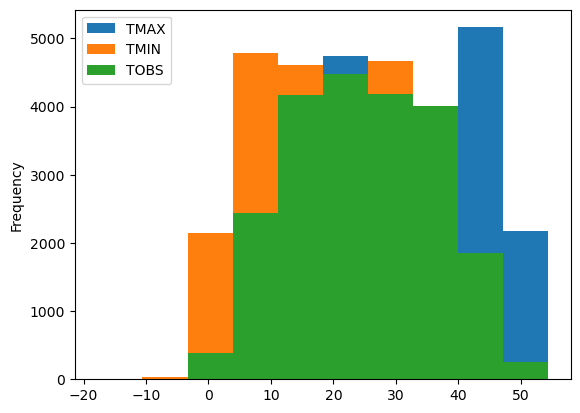

In [5]:
### Check distribution of missing temperature values (NaNs)
climate_df.plot.hist()

In [6]:
### Check data for null values
climate_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21914 entries, 1962-01-01 to 2021-12-31
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  21914 non-null  object 
 1   TMAX     21877 non-null  float64
 2   TMIN     21851 non-null  float64
 3   TOBS     21766 non-null  float64
dtypes: float64(3), object(1)
memory usage: 856.0+ KB


In [7]:
### filter data frame to keep temperature observed (TOBS) to new data frame
temp_df = climate_df[['TOBS']]

### rename TOBS to temp with proper unit based on selection above
if data_units == 'metric':
    temp_df = temp_df.rename(columns = {'TOBS':'temp_c'})
elif data_units == 'standard':
    temp_df = temp_df.rename(columns = {'TOBS':'temp_f'})
else:
    temp_df = temp_df.rename(columns = {'TOBS':'temp_unk'})
### check updated data frame
temp_df

,temp_c
DATE,
1962-01-01,12.8
1962-01-02,16.7
1962-01-03,15.6
1962-01-04,22.8
1962-01-05,17.2
...,...
2021-12-27,8.3
2021-12-28,7.2
2021-12-29,8.9


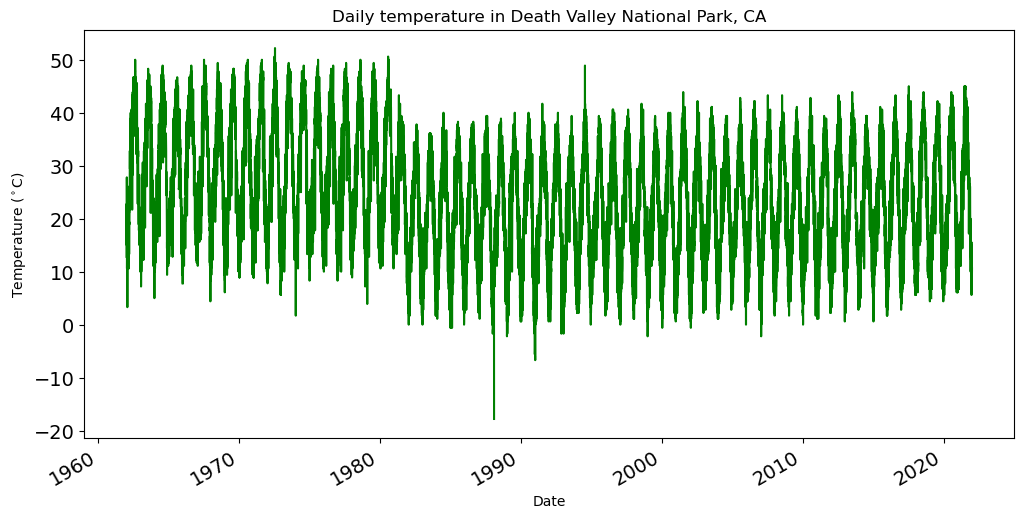

In [8]:
### Set temperature parameters based on temp format
if data_units == 'metric':
    y_set = 'temp_c'
    y_lab = 'Temperature ($^\circ$C)'
elif data_units == 'standard':
    y_set = 'temp_f'
    y_lab = 'Temperature ($^\circ$F)'
else:
    y_set = 'temp_unk'
    y_lab = 'Temperature'

### Plot daily temperature observtions (formatted)


temp_modified = temp_df.plot(
    y = y_set,        
    title = 'Daily temperature in '+station_name,
    xlabel = 'Date',
    ylabel = y_lab,
    figsize = (12,6),
    fontsize = 14,
    color = 'green',
    #kind = 'bar'
    )

temp_modified.legend().remove()

There is a clear shift in the daily observed temperature range. Further investigation indicates that in 1981 the observation collection time, for both temperature and precipitation, shifted from 1600 LST to 0800 LST with May 31 1981 being the last data collection at 1600 and Jun 1 1981 being the first data collected at 0800. Furthermore, on Nov 2 2015, the observation collection time shifted to 2359 LST, though the shift from 0800 to 2359 is much less visually evident on the plot of daily observations. (https://www.weather.gov/media/vef/Climate/Death%20Valley%20Climate%20Book/Precipitation%20History%20%26%20Synopsis.pdf)

In [9]:
### find mean annual temp

ann_temp_df = (
    temp_df # data source
    .resample('YS') # resample frequency: annual/year start
    .mean() # aggregation method
)

ann_temp_df

,temp_c
DATE,
1962-01-01,30.929945
1963-01-01,30.100549
1964-01-01,30.120994
1965-01-01,29.466391
1966-01-01,30.798061
1967-01-01,30.046301
1968-01-01,30.045082
1969-01-01,29.961096
1970-01-01,29.893425


<Axes: title={'center': 'Mean annual temperature in Death Valley National Park, CA'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

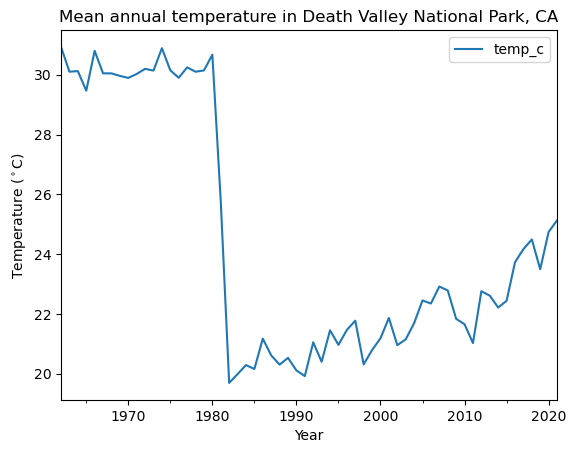

In [10]:
ann_temp_df.plot(
    y = 'temp_c',
    title = 'Mean annual temperature in '+station_name,
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

In [10]:
hvplot.extension("bokeh")

### plot the annual data interactively

ann_temp_plot = ann_temp_df.hvplot(
    y = 'temp_c',
    title = 'Mean annual temperature in '+station_name,
    xlabel = 'Year',
    ylabel = 'Temperature (deg C)'
)

ann_temp_plot

:Curve   [DATE]   (temp_c)

In [12]:
hv.save(ann_temp_plot, 'annual_temp_plot_death_valley.html')

In [11]:
all_temps_df = climate_df[['TOBS','TMIN','TMAX']]

if data_units == 'metric':
    all_temps_df = all_temps_df.rename(columns = {'TOBS':'t_obs_c','TMIN':'t_min_c','TMAX':'t_max_c'})
elif data_units == 'standard':
   all_temps_df = all_temps_df.rename(columns = {'TOBS':'t_obs_f','TMIN':'t_min_f','TMAX':'t_max_f'})
else:
    all_temps_df = all_temps_df.rename(columns = {'TOBS':'t_obs_unk','TMIN':'t_min_unk','TMAX':'t_max_unk'})
### check updated data frame
all_temps_df

,t_obs_c,t_min_c,t_max_c
DATE,,,
1962-01-01,12.8,6.7,13.9
1962-01-02,16.7,2.2,17.2
1962-01-03,15.6,2.2,18.3
1962-01-04,22.8,5.0,23.3
1962-01-05,17.2,7.8,22.8
...,...,...,...
2021-12-27,8.3,8.3,16.7
2021-12-28,7.2,5.0,12.8
2021-12-29,8.9,2.2,11.1


In [12]:
### find mean annual temp for each measurement

ann_temps_df = (
    all_temps_df # data source
    .resample('YS') # resample frequency: annual/year start
    .mean() # aggregation method
)

ann_temps_df

,t_obs_c,t_min_c,t_max_c
DATE,,,
1962-01-01,30.929945,17.617808,33.011781
1963-01-01,30.100549,17.309315,32.326027
1964-01-01,30.120994,17.095068,32.067397
1965-01-01,29.466391,16.346703,31.821978
1966-01-01,30.798061,16.847207,32.816022
1967-01-01,30.046301,17.077901,32.444658
1968-01-01,30.045082,17.360656,32.486612
1969-01-01,29.961096,17.735165,32.297808
1970-01-01,29.893425,17.560548,32.327123


In [15]:

### plot the annual data interactively

ann_temps_plot = ann_temps_df.hvplot(
    y = ['t_min_c','t_obs_c','t_max_c'],
    title = 'Mean annual temperature in '+station_name,
    xlabel = 'Year',
    ylabel = 'Temperature (deg C)'
)

ann_temps_plot

:NdOverlay   [Variable]
   :Curve   [DATE]   (value)

In [16]:
hv.save(ann_temps_plot, 'annual_all_temps_plot_death_valley.html')

In [13]:
### verify data set does not have any NaN values
na_chk = ann_temp_df.isna().sum()
print(na_chk)

if na_chk.max() != 0:
    ### remove na data from data frame
    ann_temp_df = ann_temp_df.dropna()

    ### verify data set does not have any NaN values
    print(ann_temp_df.isna().sum())

### filter data (if required)
clean_ann_temp_df = ann_temp_df

### year groupings for looking at different slopes
grp1_yr_start = '1962'
grp1_yr_end = '1980'
grp2_yr_start = '1982'
grp2_yr_end = '2021'

clean_ann_temp_df.head()

### create two subset groups of years that show different slopes
### 1962-1981
early_ann_temp_df = clean_ann_temp_df.loc[grp1_yr_start:grp1_yr_end]
### 1982-2021
late_ann_temp_df = clean_ann_temp_df.loc[grp2_yr_start:grp2_yr_end]


temp_c    0
dtype: int64


In [ ]:
### verify data set does not have any NaN values
na_chk_all = ann_temps_df.isna().sum()
print(na_chk_all)

if na_chk_all.max() != 0:
    ### remove na data from data frame
    ann_temps_df = ann_temps_df.dropna()

    ### verify data set does not have any NaN values
    print(ann_temps_df.isna().sum())


t_obs_c    0
t_min_c    0
t_max_c    0
dtype: int64


In [ ]:
### fit an OLS Linear Regression to all of the observed data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
x = clean_ann_temp_df.index.year.values.reshape(-1, 1)

### define dependent variable
y = clean_ann_temp_df.temp_c

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(x, y)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: -0.15449589350834406 degrees per year


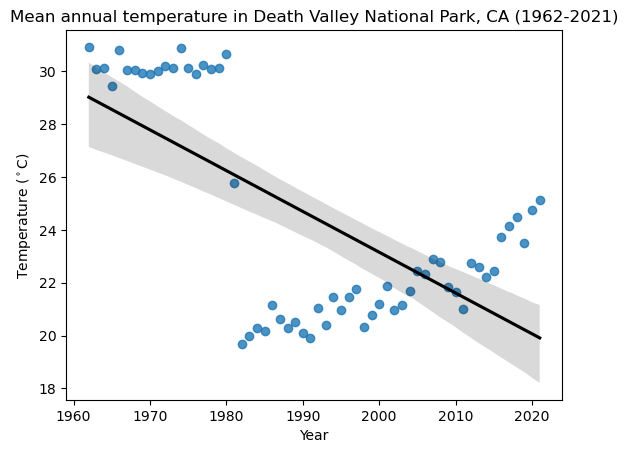

In [15]:
### plot data for OLS Linear Regression of all data
ax = sns.regplot(
    x = clean_ann_temp_df.index.year, 
    y = clean_ann_temp_df.temp_c,

    line_kws={"color": "black"} # trendline color
)


### make labels
ax.set(
    title = 'Mean annual temperature in '+station_name+' (' +grp1_yr_start+'-'+grp2_yr_end +')',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save plot
plt.savefig('/workspaces/01-climate-fall-template/mean_ann_temp_w_trend_dvnp.jpeg')

### plot it
plt.show()

In [16]:
### rerun regression for the two subset year groups

x1 = early_ann_temp_df.index.year.values.reshape(-1, 1)
y1 = early_ann_temp_df.temp_c

x2 = late_ann_temp_df.index.year.values.reshape(-1, 1)
y2 = late_ann_temp_df.temp_c

### fit the model on the data
mod1 = model.fit(x1, y1)

### calculate and print metrics
print(f'Early Slope: {mod1.coef_[0]} degrees per year')

### fit the model on the data
mod2 = model.fit(x2, y2)

### calculate and print metrics
print(f'Late Slope: {mod2.coef_[0]} degrees per year')


Early Slope: 0.0028590726478588246 degrees per year
Late Slope: 0.10630597099278415 degrees per year


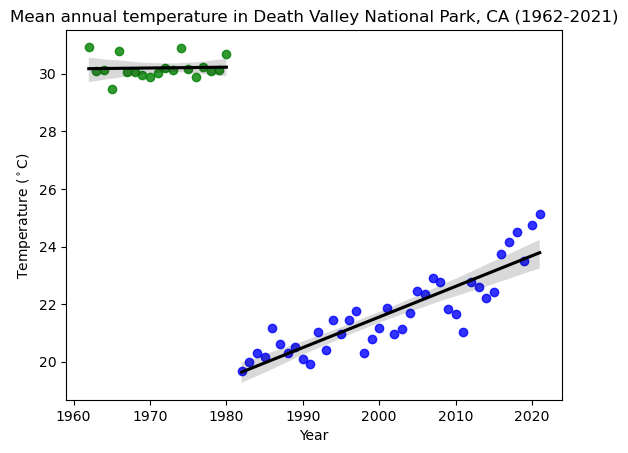

In [17]:
### plot data for OLS Linear Regression of split data groups
### Group 1
ax = sns.regplot(
    x = early_ann_temp_df.index.year, 
    y = early_ann_temp_df.temp_c,
    label = grp1_yr_start+'-'+grp1_yr_end ,

    color = 'green', # points color

    line_kws={"color": "black"} # trendline color
)
### Group 2
ax = sns.regplot(
    x = late_ann_temp_df.index.year, 
    y = late_ann_temp_df.temp_c,
    label = grp1_yr_start+'-'+grp1_yr_end,

    color = 'blue', # points color

    line_kws={"color": "black"} # trendline color
)


### make labels
ax.set(
    title = 'Mean annual temperature in '+station_name+' (' +grp1_yr_start+'-'+grp2_yr_end +')',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save plot
plt.savefig('/workspaces/01-climate-fall-template/mean_ann_temp_w_trend_split_dvnp.jpeg')

### plot it
plt.show()

In [20]:
### fit an OLS Linear Regression to all of the minimum temperature data

tmin_df = ann_temps_df[['t_min_c']]

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
x_min = tmin_df.index.year.values.reshape(-1, 1)

### define dependent variable
y_min = tmin_df.t_min_c

### make linear regression model
model = LinearRegression()

### fit the model on the data
mod_min = model.fit(x_min, y_min)

### calculate and print metrics
print(f'Slope: {mod_min.coef_[0]} degrees per year')

Slope: 0.023916148062692176 degrees per year


In [21]:
### fit an OLS Linear Regression to all of the maximum temperature data

tmax_df = ann_temps_df[['t_max_c']]

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
x_max = tmax_df.index.year.values.reshape(-1, 1)

### define dependent variable
y_max = tmax_df.t_max_c

### make linear regression model
model = LinearRegression()

### fit the model on the data
mod_max = model.fit(x_max, y_max)

### calculate and print metrics
print(f'Slope: {mod_max.coef_[0]} degrees per year')

Slope: 0.033207165890431024 degrees per year


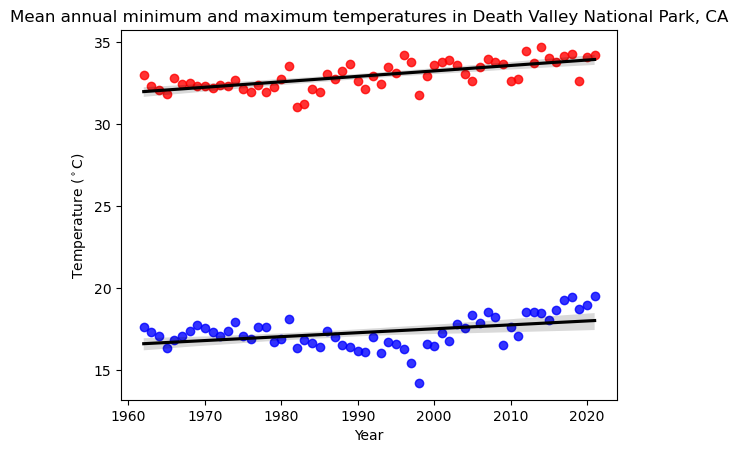

In [23]:
### plot data for OLS Linear Regression of minimum and maximum temperature groups
### minimum
ax = sns.regplot(
    x = x_min, 
    y = y_min,
    label = 'minimum' ,

    color = 'blue', # points color

    line_kws={"color": "black"} # trendline color
)
### maximum
ax = sns.regplot(
    x = x_max, 
    y = y_max,
    label = 'maximum',

    color = 'red', # points color

    line_kws={"color": "black"} # trendline color
)


### make labels
ax.set(
    title = 'Mean annual minimum and maximum temperatures in '+station_name,
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save plot
plt.savefig('/workspaces/01-climate-fall-template/mean_ann_temp_w_min_max_dvnp.jpeg')

### plot it
plt.show()

In [28]:
### Build map of Death Valley National Park

### Search for Death Valley National Park

dvnp_gdf = osm.features_from_address(
    name = 'Death Valley National Park', 
    boundary = 'protected_area',
    dist = 500
)

dvnp_gdf

TypeError: features_from_address() got an unexpected keyword argument 'name'

In [ ]:
### Search for Death Valley National Park Weather Station
### Coordinates: 36.46263, -116.8672

point = (36.46263, -116.8672)